In [6]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns


In [7]:
import os

folder_path = "./data"

print("="*60)
print("Files available in folder")
print("="*60)

files = os.listdir(folder_path)
for file in files:
    file_size = os.path.getsize(os.path.join(folder_path, file)) / (1024 * 1024)
    print(f" {file} - {file_size:.2f} MB")

print("="*60)

file_name = "compas-scores-two-years.csv"
file_path = os.path.join(folder_path, file_name)

try:
    df = pd.read_csv(file_path, low_memory=False)
    print(" File loaded!")
    print(f" {df.shape[0]:,} rows")
    print(f" {df.shape[1]} columns")
except FileNotFoundError:
    print(f"\n File not found!")
    print(f"\n Files available")
    for file in files:
        if file.endswith('.csv'):
            print(f" - {file}")

    csv_files = [f for f in files if f.endswith('.csv')]
    if csv_files:
        file_name = csv_files [0]
        file_path = os.path.join(folder_path, file_name)
        df = pd.read_csv(file_path, low_memory=False)
        print(f"\n Alternative file: {file_name}")
        print(f" {df.shape[0]:,} rows")
        print(f" {df.shape[1]} columns")
    



Files available in folder
 .ipynb_checkpoints - 0.00 MB
 best_model_optimized.pkl - 0.36 MB
 compas-scores-raw.csv - 12.10 MB
 compas-scores-two-years.csv - 2.43 MB
 config.json - 0.00 MB
 ML RECIDIVISM MODEL.ipynb - 1.05 MB
 model_results.csv - 0.00 MB
 predictor.pkl - 0.36 MB
 scaler.pkl - 0.00 MB
 File loaded!
 7,214 rows
 53 columns


In [10]:
print("="*60)
print("Summary dataset")
print("="*60)

print(f" Set loaded successfully")
print(f" {df.shape[0]:,} rows")
print(f" {df.shape[1]} columns")

print("\n First 3 records")
display(df.head(3))

print(f"\n List of columns ({len(df.columns)}):")
for i, col in enumerate (df.columns, 1):
    print(f"  {i:2d}. {col}")



Summary dataset
 Set loaded successfully
 7,214 rows
 53 columns

 First 3 records


,id,name,first,last,compas_screening_date,sex,dob,age,age_cat,race,...,v_decile_score,v_score_text,v_screening_date,in_custody,out_custody,priors_count.1,start,end,event,two_year_recid
0,1,miguel hernandez,miguel,hernandez,2013-08-14,Male,1947-04-18,69,Greater than 45,Other,...,1,Low,2013-08-14,2014-07-07,2014-07-14,0,0,327,0,0
1,3,kevon dixon,kevon,dixon,2013-01-27,Male,1982-01-22,34,25 - 45,African-American,...,1,Low,2013-01-27,2013-01-26,2013-02-05,0,9,159,1,1
2,4,ed philo,ed,philo,2013-04-14,Male,1991-05-14,24,Less than 25,African-American,...,3,Low,2013-04-14,2013-06-16,2013-06-16,4,0,63,0,1



 List of columns (53):
   1. id
   2. name
   3. first
   4. last
   5. compas_screening_date
   6. sex
   7. dob
   8. age
   9. age_cat
  10. race
  11. juv_fel_count
  12. decile_score
  13. juv_misd_count
  14. juv_other_count
  15. priors_count
  16. days_b_screening_arrest
  17. c_jail_in
  18. c_jail_out
  19. c_case_number
  20. c_offense_date
  21. c_arrest_date
  22. c_days_from_compas
  23. c_charge_degree
  24. c_charge_desc
  25. is_recid
  26. r_case_number
  27. r_charge_degree
  28. r_days_from_arrest
  29. r_offense_date
  30. r_charge_desc
  31. r_jail_in
  32. r_jail_out
  33. violent_recid
  34. is_violent_recid
  35. vr_case_number
  36. vr_charge_degree
  37. vr_offense_date
  38. vr_charge_desc
  39. type_of_assessment
  40. decile_score.1
  41. score_text
  42. screening_date
  43. v_type_of_assessment
  44. v_decile_score
  45. v_score_text
  46. v_screening_date
  47. in_custody
  48. out_custody
  49. priors_count.1
  50. start
  51. end
  52. event
  53. tw

In [11]:
print("="*60)
print("EDA")
print("="*60)

print("\n Structure:")
print(f" {df.shape[0]:,} randuri")
print(f" {df.shape[1]} coloane")

print("\Missing values")
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing' : missing,
    '%' : missing_pct
})
missing_df = missing_df[missing_df['Missing'] > 0 ].sort_values('Missing', ascending=False)
print (missing_df)

print("\n Duplicates")
dup_all = df.duplicated().sum()
print (f" Complete: {dup_all}")

if 'Person_ID' in df.columns:
    dup_id = df.duplicated(subset=['Person_ID', 'DisplayText']).sum()
    print(f" Person_ID + DisplayText: {dup_id}")

print("\n Numerical Statistics")
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
print(df[num_cols].describe())

print("\n Categorical Variables")
cat_cols = df.select_dtypes(include=['object']).columns

for col in cat_cols[:3]:
    print(f"\n {col}:")
    print(f" Valori unice: {df[col].nunique()}")
    if df[col].nunique() <= 10:
        print(df[col].value_counts())

print("\n Target Variables")
target_col = [col for col in df.columns if 'recid' in col.lower() or 'Risk' in col]
print(f" Gasite: {target_col}")

for col in target_col:
    if col in df.columns:
        print(f"\n {col}:")
        print(f" Type: {df[col].dtype}")
        print(f" Unique Values: {df[col].unique}")
        print(f" Distribution:")
        print(df[col].value_counts())
print("n\ Done")


EDA

 Structure:
 7,214 randuri
 53 coloane
\Missing values
                         Missing           %
violent_recid               7214  100.000000
vr_charge_desc              6395   88.647075
vr_offense_date             6395   88.647075
vr_charge_degree            6395   88.647075
vr_case_number              6395   88.647075
c_arrest_date               6077   84.238980
r_jail_out                  4898   67.895758
r_days_from_arrest          4898   67.895758
r_jail_in                   4898   67.895758
r_charge_desc               3801   52.689215
r_offense_date              3743   51.885223
r_case_number               3743   51.885223
r_charge_degree             3743   51.885223
c_offense_date              1159   16.065983
days_b_screening_arrest      307    4.255614
c_jail_in                    307    4.255614
c_jail_out                   307    4.255614
in_custody                   236    3.271417
out_custody                  236    3.271417
c_charge_desc                 29    0.40

In [12]:
print("="*60)
print("Eliminare coloane")
print("="*60)

#coloane cu mai mul de 80%valori lipsa
high_missing = missing_df[missing_df ['%'] > 80].index.tolist()
print(f"\n Columns to eliminate (>80% missing): ")
for col in high_missing:
    print(f" - {col}:{missing_df.loc[col, 'Missing']:,} ({missing_df.loc[col, '%']:.1f}%")

df_clean = df.drop(columns=high_missing)
print(f"\n Eliminate {len(high_missing)} columns")
print(f" - Remained: {df_clean.shape[1]} columns")

Eliminare coloane

 Columns to eliminate (>80% missing): 
 - violent_recid:7,214 (100.0%
 - vr_charge_desc:6,395 (88.6%
 - vr_offense_date:6,395 (88.6%
 - vr_charge_degree:6,395 (88.6%
 - vr_case_number:6,395 (88.6%
 - c_arrest_date:6,077 (84.2%

 Eliminate 6 columns
 - Remained: 47 columns


In [13]:
print("="*60)
print("Treating missing values")
print("="*60)

print("\n Eliminate missing columns:")
cols_100_empty = [col for col in df.columns if df[col].isnull().all()]
for col in cols_100_empty:
    print(f" - {col}: 100% missing values -> eliminate")

df_clean = df.drop(columns=cols_100_empty)
print("\n Eliminate {len(cols_100_empty)} columns")
print(f" Remained: {df_clean.shape[1]} columns")

print("\n Eliminate columns with 80% missing values:")
missing_pct = (df_clean.isnull().sum() / len(df_clean)) * 100
high_missing = missing_pct[missing_pct > 80].index.tolist()

for col in high_missing:
    print(f" - {col}: {missing_pct[col]:.1f}%missing ->eliminate")

df_clean = df_clean.drop(columns=high_missing) 
print(f"\n Eliminate {len(high_missing)} columns")
print(f" Remained: {df_clean.shape[1]} columns")

print("\n Treating missing values:")

#coloane numerice-mediana
num_cols = df_clean.select_dtypes(include=['int',  'float64']).columns
for col in num_cols:
    if df_clean[col].isnull().sum() > 0:
        medie = df_clean[col].median()
        df_clean[col] = df_clean[col].fillna(medie)
        print(f" {col}: complete with median ({medie:.2f})")

#coloane text "Unknown"
cat_cols = df_clean.select_dtypes(include=['object']).columns
for cat in cat_cols:
    if df_clean[col].isnull().sum() > 0:
        df_clean[col] = df_clean[col].fillna ('Unknown')
        print(f" {col}: complete with 'Unknown'")

print("\n" + "="*60)
print("Checked")
print("="*60)

Treating missing values

 Eliminate missing columns:
 - violent_recid: 100% missing values -> eliminate

 Eliminate {len(cols_100_empty)} columns
 Remained: 52 columns

 Eliminate columns with 80% missing values:
 - c_arrest_date: 84.2%missing ->eliminate
 - vr_case_number: 88.6%missing ->eliminate
 - vr_charge_degree: 88.6%missing ->eliminate
 - vr_offense_date: 88.6%missing ->eliminate
 - vr_charge_desc: 88.6%missing ->eliminate

 Eliminate 5 columns
 Remained: 47 columns

 Treating missing values:
 days_b_screening_arrest: complete with median (-1.00)
 c_days_from_compas: complete with median (1.00)
 r_days_from_arrest: complete with median (0.00)

Checked


Visualization

 1.Distribution Recide


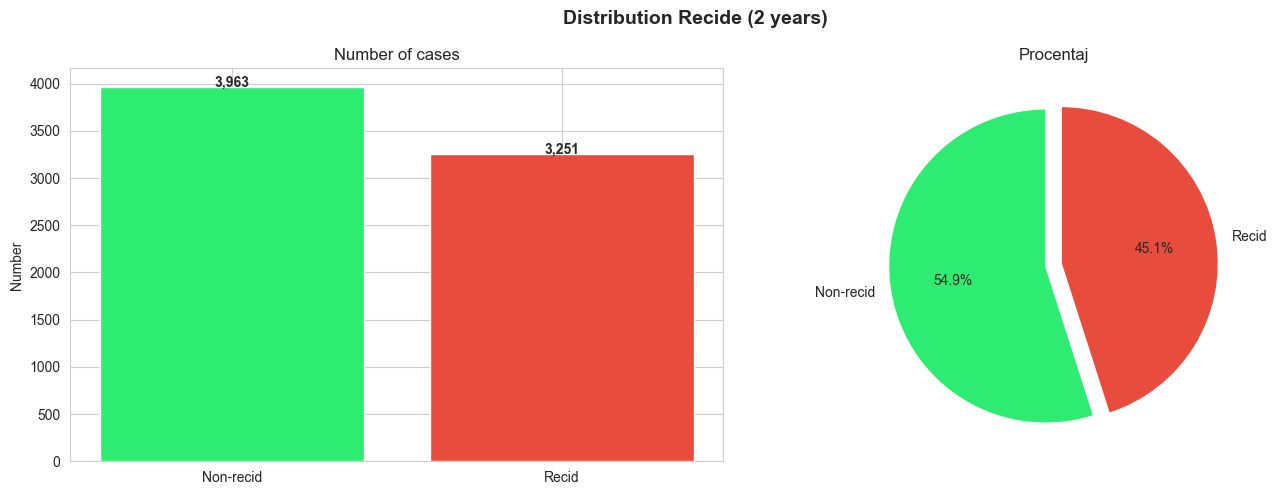


 2. Age VS Recid


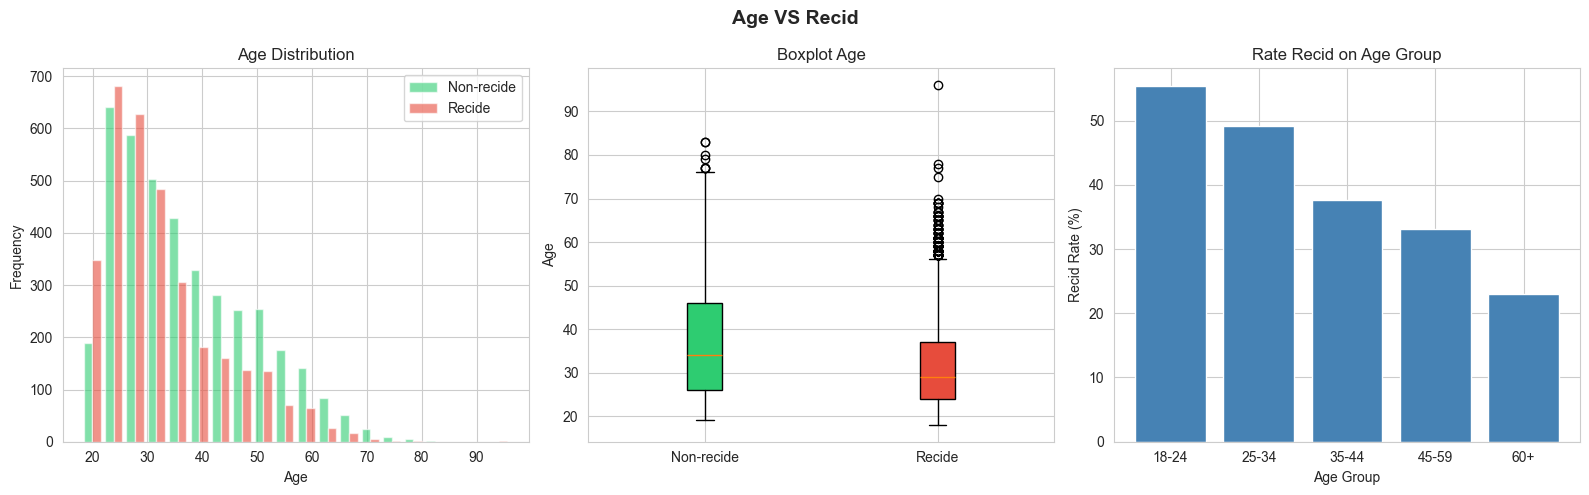


 3. Scores Compas VS Recid


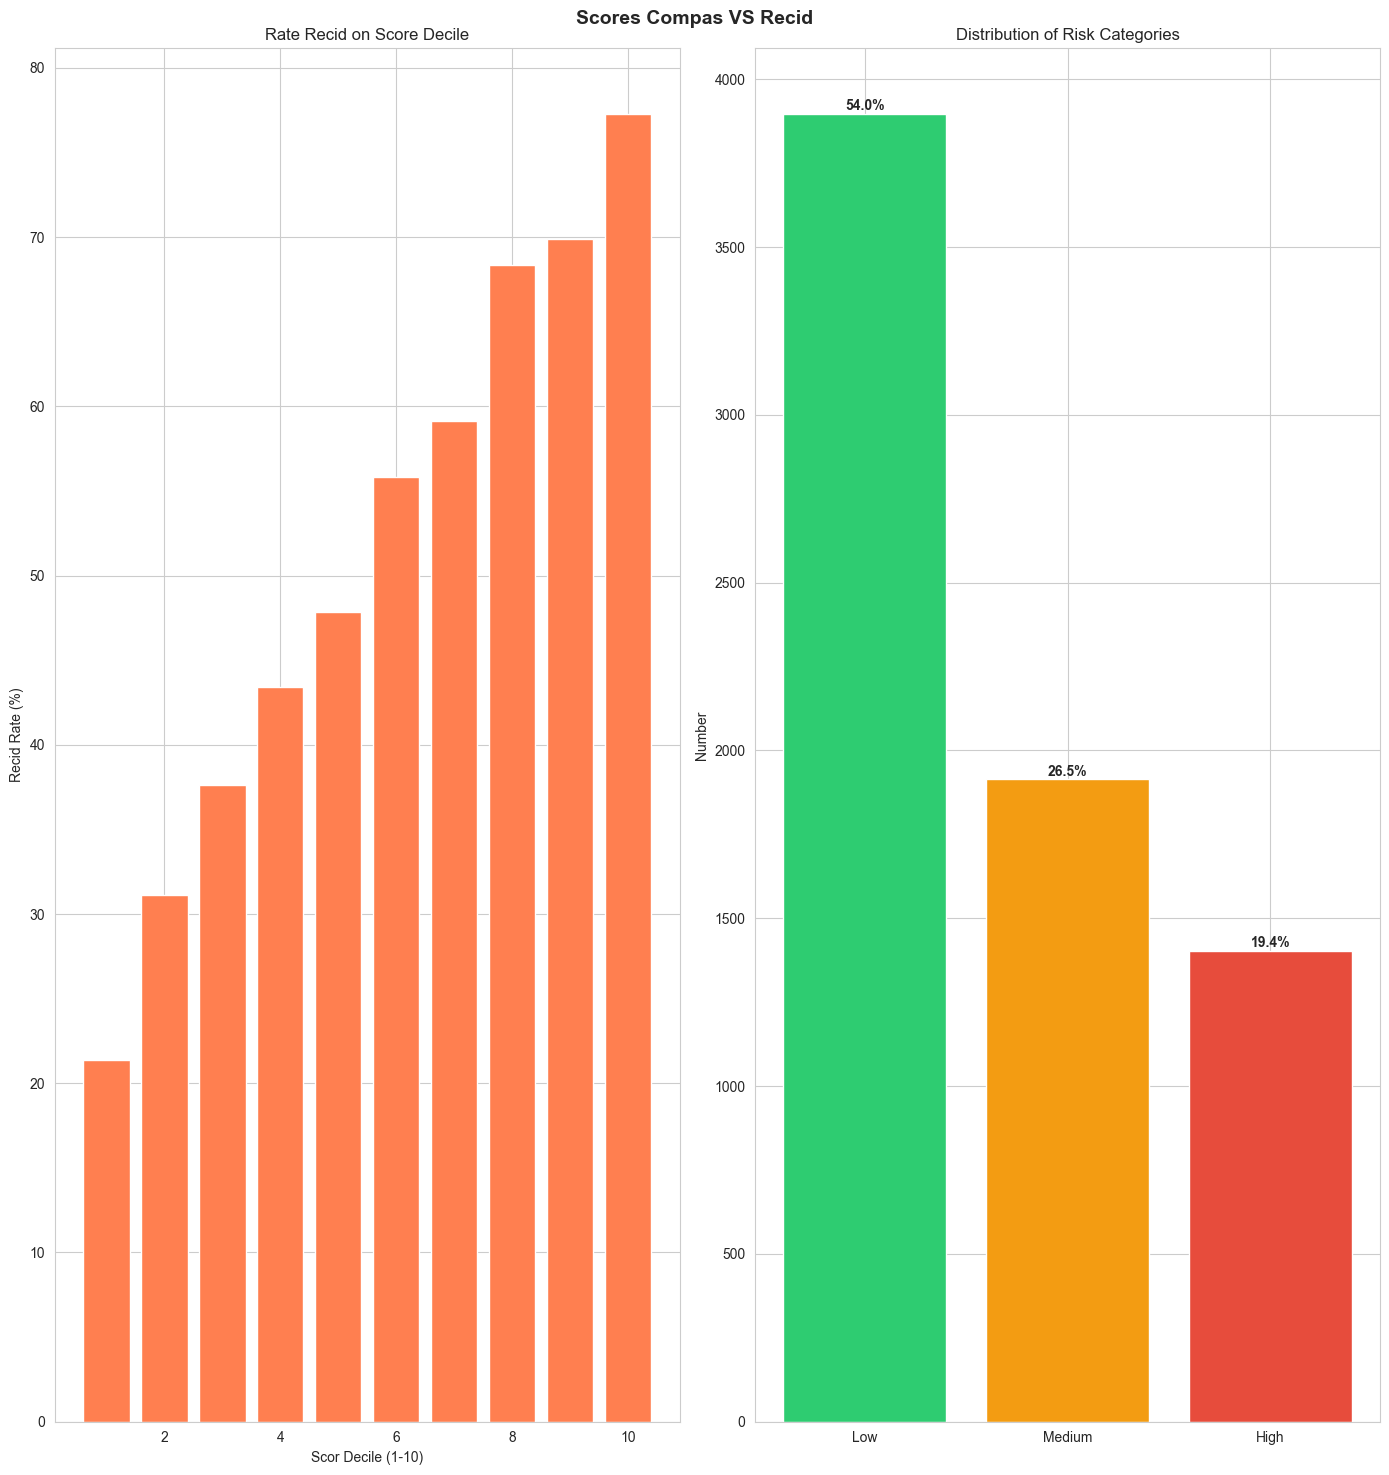


 Demographic Analysis


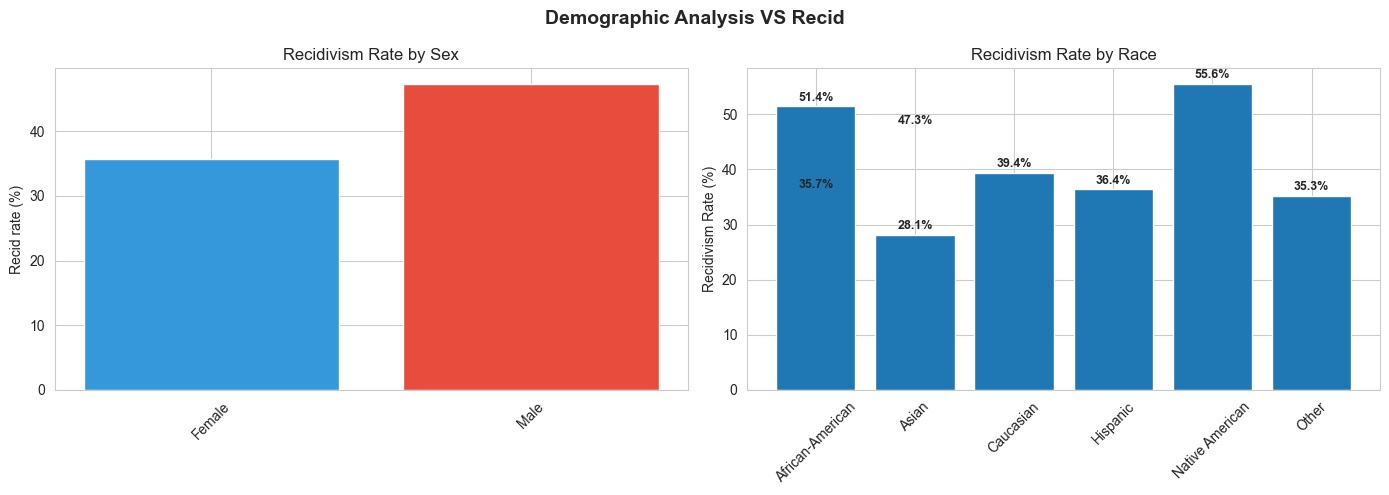


 Criminal History VS Recid


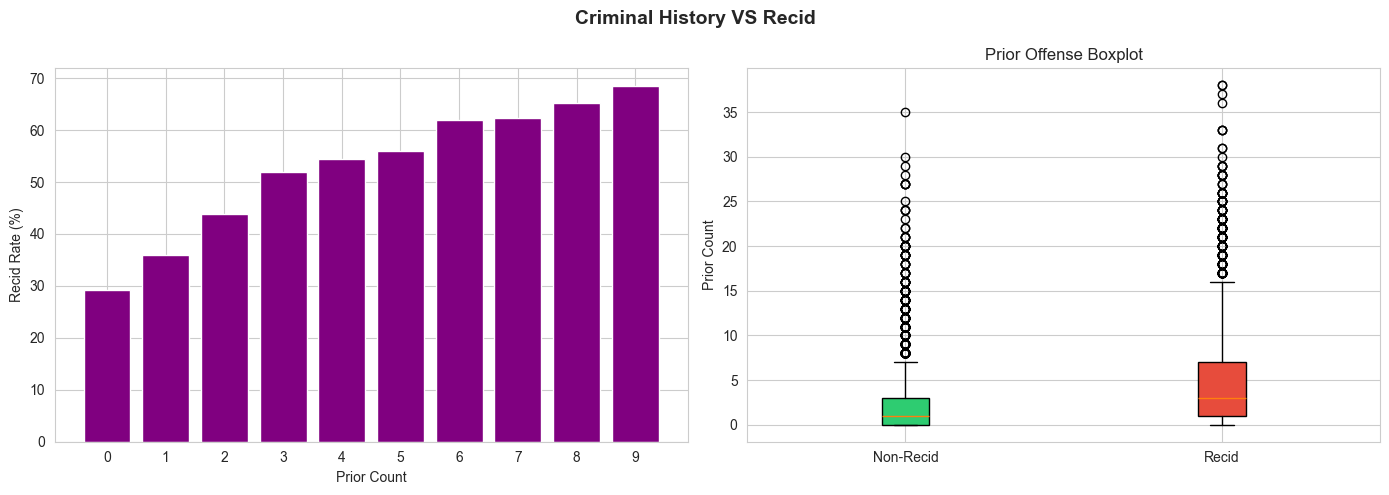


 Correlation between variables


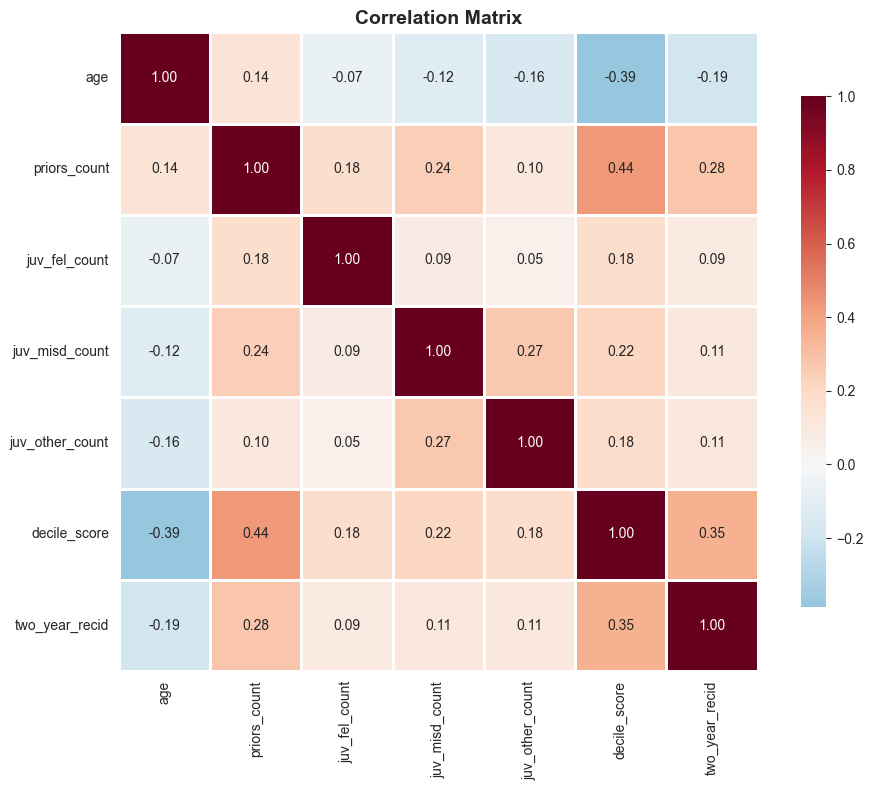


 Correlation with two_year_recid:
 - decile_score: 0.351
 - priors_count: 0.275
 - juv_misd_count: 0.109
 - juv_other_count: 0.108
 - juv_fel_count: 0.093
 - age: -0.190


In [15]:
import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("="*60)
print("Visualization")
print("="*60)

#1.target variable - two_year_recid
print("\n 1.Distribution Recide")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Distribution Recide (2 years)', fontsize= 14, fontweight='bold')

#countplot
counts = df_clean['two_year_recid'].value_counts()
labels = ['Non-recid', 'Recid']
colors = ['#2eec71', '#e74c3c']

bars = axes[0]. bar(labels, counts.values, color=colors)
axes[0].set_title('Number of cases')
axes[0].set_ylabel('Number')
for bar, count in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                 f'{count:,}', ha='center', fontweight='bold')
#pie chart
percentages = df_clean['two_year_recid'].value_counts(normalize=True) * 100
axes[1].pie(percentages.values, labels=labels, autopct='%1.1f%%', colors=colors, startangle=90, explode=(0.05,0.05))
axes[1].set_title('Procentaj')

plt.tight_layout()
plt.show()

#2.age vs recid
print("\n 2. Age VS Recid")

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Age VS Recid', fontsize=14, fontweight='bold')

#histogram
axes[0].hist([df_clean[df_clean['two_year_recid']==0]['age'],
              df_clean[df_clean['two_year_recid']==1]['age']],
             bins=20, label=['Non-recide', 'Recide'],
             color=['#2ecc71', '#e74c3c'], alpha=0.6)
axes[0].set_title('Age Distribution')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Frequency')
axes[0].legend()

#boxplot
data = [df_clean[df_clean['two_year_recid']==0]['age'],df_clean[df_clean['two_year_recid']==1]['age']]
bp = axes[1].boxplot(data, labels=['Non-recide','Recide'], patch_artist=True)
bp['boxes'][0].set_facecolor('#2ecc71')
bp['boxes'][1].set_facecolor('#e74c3c')
axes[1].set_title('Boxplot Age')
axes[1].set_ylabel('Age')

#Rate by age group
age_bins = [0, 25, 35, 45, 60, 100]
age_labels = ['18-24', '25-34', '35-44', '45-59', '60+']
df_clean['age_group'] = pd.cut(df_clean['age'], bins=age_bins, labels=age_labels)
recid_by_age = df_clean.groupby('age_group')['two_year_recid'].mean() * 100
axes[2].bar(recid_by_age.index, recid_by_age.values, color='steelblue')
axes[2].set_title('Rate Recid on Age Group')
axes[2].set_xlabel('Age Group')
axes[2].set_ylabel('Recid Rate (%)')

plt.tight_layout()
plt.show()

#3. Scores COMPAS VS Recid
print("\n 3. Scores Compas VS Recid")

fig, axes = plt.subplots(1, 2, figsize=(14, 15))
fig.suptitle('Scores Compas VS Recid', fontsize=14, fontweight='bold')

#Recid rate on score decile
recid_by_score = df_clean.groupby('decile_score')['two_year_recid'].mean() * 100
axes[0].bar(recid_by_score.index, recid_by_score.values, color='coral')
axes[0].set_title('Rate Recid on Score Decile')
axes[0].set_xlabel('Scor Decile (1-10)')
axes[0].set_ylabel('Recid Rate (%)')

#Risk Categories
if 'score_text' in df_clean.columns:
    risk_counts = df_clean['score_text'].value_counts()
    color_risk = {'Low': '#2ecc71', 'Medium': '#f39c12', 'High': '#e74c3c'}
    axes[1].bar(risk_counts.index, risk_counts.values, color=[color_risk.get(x, 'gray') for x in risk_counts.index])
    axes[1].set_title('Distribution of Risk Categories')
    axes[1].set_ylabel('Number')
    #adding procentages
    for i, (idx, val) in enumerate(risk_counts.items()):
        pct = val / len(df_clean) * 100
        axes[1].text(i, val + 10, f'{pct:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

#4.Demographic analysis
print("\n Demographic Analysis")

fig, axes = plt.subplots(1, 2, figsize=(14,5))
fig.suptitle('Demographic Analysis VS Recid', fontsize=14, fontweight='bold')

#sex
if 'sex' in df_clean.columns:
    recid_by_sex = df_clean.groupby('sex')['two_year_recid'].mean() * 100
    axes[0].bar(recid_by_sex.index, recid_by_sex.values, color=['#3498db', '#e74c3c'])
    axes[0].set_title('Recidivism Rate by Sex')
    axes[0].set_ylabel('Recid rate (%)')
    axes[0].tick_params(axis='x', rotation=45)
    #adding values
    for i, (idx, val) in enumerate(recid_by_sex.items()):
        axes[1].text(i, val + 1, f'{val:.1f}%', ha='center', fontweight='bold', fontsize=9)
#race
if 'race' in df_clean.columns:
    recid_by_race = df_clean.groupby('race')['two_year_recid'].mean() * 100
    axes[1].bar(recid_by_race.index, recid_by_race.values)
    axes[1].set_title('Recidivism Rate by Race')
    axes[1].set_ylabel('Recidivism Rate (%)')
    axes[1].tick_params(axis='x', rotation=45)
    #adding values
    for i, (idx, val) in enumerate(recid_by_race.items()):
        axes[1].text(i, val + 1, f'{val:.1f}%', ha='center', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()

#5.Criminal History VS Recid
print("\n Criminal History VS Recid")

fig, axes = plt.subplots(1, 2, figsize=(14,5))
fig.suptitle('Criminal History VS Recid', fontsize=14, fontweight='bold')

#Recidivsm Rate by Prior (Top 10)
if 'priors_count' in df_clean.columns:
    recid_by_priors = df_clean.groupby('priors_count')['two_year_recid'].mean() * 100
    recid_by_priors_top=recid_by_priors.head(10)
    axes[0].bar(recid_by_priors_top.index.astype(str), recid_by_priors_top.values, color='purple')
    axes[0].set_xlabel('Prior Count')
    axes[0].set_ylabel('Recid Rate (%)')

#boxplot criminal history vs recid
data_priors = [df_clean[df_clean['two_year_recid']==0]['priors_count'], 
               df_clean[df_clean['two_year_recid']==1]['priors_count']]
bp = axes[1].boxplot(data_priors, labels=['Non-Recid', 'Recid'], patch_artist=True)
bp['boxes'][0].set_facecolor('#2ecc71')
bp['boxes'][1].set_facecolor('#e74c3c')
axes[1].set_title('Prior Offense Boxplot')
axes[1].set_ylabel('Prior Count')
plt.tight_layout()
plt.show()

#6. Correlation Matrix
print("\n Correlation between variables")

#select relevant number columns
corr_cols = ['age', 'priors_count', 'juv_fel_count', 'juv_misd_count','juv_other_count', 'decile_score', 'two_year_recid']
existing_corr = [col for col in corr_cols if col in df_clean.columns]

if len(existing_corr) > 1:
    plt.figure(figsize=(10,8))
    corr_matrix = df_clean[existing_corr].corr()
    sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0, fmt='.2f', square=True, linewidths=1, cbar_kws={"shrink": 0.8})
    plt.title('Correlation Matrix', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

    #correlation with two_year_recid
    print("\n Correlation with two_year_recid:")
    corr_with_target = corr_matrix['two_year_recid'].drop('two_year_recid').sort_values(ascending=False)
    for var, corr in corr_with_target.items():
        print(f" - {var}: {corr:.3f}")
    
    
    

    



    

    

             
            





In [16]:
#Feature Engineering-creating new variables
print("="*60)
print("Feature Engineering")
print("="*60)

#a copy for safety 
df_model = df_clean.copy()

#1.Priors per age ratio
print("\n Create variable: priors_per_age")

if 'priors_count' in df_model.columns and 'age' in df_model.columns:
    df_model['priors_per_age'] = df_model['priors_count'] / (df_model['age'] + 1)
    print(f" priors_per_age created")
    print(f"  - Mean: {df_model['priors_per_age'].mean():.3f}")
    print(f"  - Min: {df_model['priors_per_age'].min():.3f}")
    print(f"  - Max: {df_model['priors_per_age'].max():.3f}")

#2.Total RISK score
print("\n Create variable: total_risk_score")

if 'decile_score' in df_model.columns and 'decile_score.1' in df_model.columns:
    df_model['total_risk_score'] = df_model['decile_score'] + df_model['decile_score.1']
    print(f" total_risk_score created")
    print(f"  - Mean:{df_model['total_risk_score'].mean():.2f}")
    print(f"  - Min:{df_model['total_risk_score'].min():.0f}")
    print(f"  - Max:{df_model['total_risk_score'].max():.0f}")
else:
    print(f" decile_score.1 not found, using only decile_score")
    df_model['total_risk_score'] = df_model['decile_score']
    print(f" total_risk_score created ( from decile_score only")

#3. High Risk Flag
print("\n Create variable: high_risk_flag")

if 'decile_score' in df_model.columns:
    df_model['high_risk_flag'] = (df_model['decile_score'] >= 7).astype(int)
    print(f" high_risk_flag created")
    print(f"  - High risk (score >= 7): {df_model['high_risk_flag'].sum():,} ({df_model['high_risk_flag'].mean()*100:.1f}%)")
    print(f"  - Low risk (score < 7): {(df_model['high_risk_flag'] == 0).sum():,} ({(1 - df_model['high_risk_flag'].mean())*100:.1f}%)")

#4. Total Juvenile Record
print("\n 4. Create variable: total_juv_count")

juv_cols = ['juv_fel_count', 'juv_misd_count', 'juv_other_count']
existing_juv = [col for col in juv_cols if col in df_model.columns]

if len(existing_juv) >= 2:
    df_model['total_juv_count'] = df_model[existing_juv].sum(axis=1)
    print(f" total_juv_count created from: {existing_juv}")
    print(f"  - Mean:{df_model['total_juv_count'].mean():.2f}")
    print(f"  - Max:{df_model['total_juv_count'].min():.0f}")
    print(f"  - Have juvenile record: {(df_model['total_juv_count'] > 0).sum():,} ({(df_model['total_juv_count'] > 0).mean()*100:.1f}%)")

#5.Has juvenile record flag
print("\n Create variable : has_juv_record")

if 'total_juv_count' in df_model.columns:
    df_model['has_juv_record'] = (df_model['total_juv_count'] > 0).astype(int)
    print(f"  has_juv_record")
    print(f"  - Has juvenile record: {df_model['has_juv_record'].sum():,} ({df_model['has_juv_record'].mean()*100:.1f}%)")
    print(f"  - No juvenile record: {(df_model['has_juv_record'] == 0).sum():,} ({( 1 - df_model['has_juv_record'].mean())*100:.1f}%)")

#Interaction Term
print("\n Create variable: priors_high_risk")

if 'priors_count' in df_model.columns and 'high_risk_flag' in df_model.columns:
    df_model['priors_high_risk'] = df_model['priors_count'] * df_model['high_risk_flag']
    print(f"  priors_high_risk created")
    print(f"  - Mean: {df_model['priors_high_risk'].mean():.2f}")

#Final verification
print("\n" + "="*60)
print("Feature Engineering Summary")
print("="*60)

print(f"\n Dataset after Feature Engineering:")
print(f" - Rows: {df_model.shape[0]:,}")
print(f" - Columns: {df_model.shape[1]}")

print("\n New features created")
new_features = ['priors_per_age', 'total_risk_score', 'high_risk_flag', 'total_juv_count', 'has_juv_record', 'priors_high_risk']

for col in new_features:
    if col in df_model.columns:
        print(f" {col}")

print("\n Distribution of new features:")
for col in new_features:
    if col in df_model.columns:
        print(f"\n {col}:")
        print(f"  - Mean: {df_model[col].mean():.3f}")
        if df_model[col].dtype in ['int64', 'float64'] and df_model[col].nunique() <= 10:
            print(f"  - Distribution:")
            print(df_model[col].value_counts().head())
print("\n" + "="*60)
print("Feature engineering complete")
print("="*60)
    

Feature Engineering

 Create variable: priors_per_age
 priors_per_age created
  - Mean: 0.099
  - Min: 0.000
  - Max: 1.077

 Create variable: total_risk_score
 total_risk_score created
  - Mean:9.02
  - Min:2
  - Max:20

 Create variable: high_risk_flag
 high_risk_flag created
  - High risk (score >= 7): 1,995 (27.7%)
  - Low risk (score < 7): 5,219 (72.3%)

 4. Create variable: total_juv_count
 total_juv_count created from: ['juv_fel_count', 'juv_misd_count', 'juv_other_count']
  - Mean:0.27
  - Max:0
  - Have juvenile record: 973 (13.5%)

 Create variable : has_juv_record
  has_juv_record
  - Has juvenile record: 973 (13.5%)
  - No juvenile record: 6,241 (86.5%)

 Create variable: priors_high_risk
  priors_high_risk created
  - Mean: 1.79

Feature Engineering Summary

 Dataset after Feature Engineering:
 - Rows: 7,214
 - Columns: 54

 New features created
 priors_per_age
 total_risk_score
 high_risk_flag
 total_juv_count
 has_juv_record
 priors_high_risk

 Distribution of new featur

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings('ignore')

print("="*60)
print("Preprocessing-Data preparation for ML")
print("="*60)

print("\n Select Features and Target")

target = 'two_year_recid'

#define features
numerical_features = [
    'age',
    'priors_count',
    'priors_per_age',
    'total_risk_score',
    'total_juv_count',
    'priors_high_risk',
]

categorical_features = [
    'sex',
    'race',
    'score_text',
    'c_charge_degree',
]

binary_features = [
    'high_risk_flag',
    'has_juv_record',
]

features = numerical_features + categorical_features + binary_features

features = [col for col in features if col in df_model.columns]

print(f" Features selected:")
print(f"  - Numerical:{len(numerical_features)}")
print(f"  - Categorical:{len(categorical_features)}")
print(f"  - Binary:{len(binary_features)}")
print(f"  - Total:{len(features)}")

#separate x and y features
print("\n Separate x and y")

X = df_model[features].copy()
y = df_model[target].copy()

print(f"\n X(features): {X.shape[0]:,} rows x {X.shape[1]} columns")
print(f"\n y(target): {y.shape[0]:,} rows")

#checks for missing values
print("\n Check for missing values")

missing_X = X.isnull().sum().sum()
missing_y = y.isnull().sum()

print(f"  - Missing in X: {missing_X}")
print(f"  - Missing in y: {missing_y}")

if missing_X == 0 and missing_y == 0:
    print(" No missing values!")
else:
    print("There are missing values!")

#encoding categorical variables
print("\n Encoding Categorical Variables")

categorical_columns = [col for col in categorical_features if col in X.columns]
print(f"\n Encoding: {categorical_columns}")

#label encoding
le_dict = {}
for col in categorical_columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    le_dict[col] = le
    print(f" {col}: {len(le.classes_)} categories encoded")

#scaling numerical variables
print("\n Scaling Numerical Variables")

numerical_columns = [col for col in numerical_features if col in X.columns]
print(f" Scaling: {numerical_columns}")

scaler = StandardScaler()
X[numerical_columns] = scaler.fit_transform(X[numerical_columns])
print(f"  {len(numerical_columns)} numerical features scaled")

#train -test split
print("\n Train-Test Split")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,
    random_state=42,
    stratify=y
)
print(f"\n Split results:")
print(f"  - Train: {X_train.shape[0]:,} rows({len(X_train)/len(X)*100:.0f}%)")
print(f"  - Test: {X_test.shape[0]:,} rows({len(X_test)/len(X)*100:.0f}%)")

print(f"\n Target Distribution(y):")
print(f" Full Dataset:")
print(f" Non-recid: {len(y[y==0]):,} ({y.mean()*100:.1f}%)")
print(f" Recid: {len(y[y==1]):,} ({y.mean()*100:.1f}%)")

print(f"\n  - Train Set: ")
print(f" Non-Recid: {len(y_train[y_train==0]):,} ({y_train.mean()*100:.1f}%)")
print(f" Recid: {len(y_train[y_train==1]):,} ({y_train.mean()*100:.1f}%)")

print(f"\n  - Test Set: ")
print(f" Non-recid: {len(y_test[y_test==0]):,} ({y_test.mean()*100:.1f}%)")
print(f" Recid: {len(y_test[y_test==1]):,} ({y_test.mean()*100:.1f}%)")

#final verification 
print("\n" + "="*60)
print("Preprocessing complete!")
print("="*60)

print(f"\n Final dataset:")
print(f"  - Features (X): {X.shape[1]} colummns")
print(f"  - Train: {X_train.shape[0]:,} rows")
print(f"  - Test: {X_test.shape[0]:,} rows")

print(f"\n Features list:")
for i, col in enumerate(X.columns, 1):
    print(f" {i:2d}. {col}")

print("\n" + "="*60)
print("Ready for model training")
print("="*60)




      



Preprocessing-Data preparation for ML

 Select Features and Target
 Features selected:
  - Numerical:6
  - Categorical:4
  - Binary:2
  - Total:12

 Separate x and y

 X(features): 7,214 rows x 12 columns

 y(target): 7,214 rows

 Check for missing values
  - Missing in X: 0
  - Missing in y: 0
 No missing values!

 Encoding Categorical Variables

 Encoding: ['sex', 'race', 'score_text', 'c_charge_degree']
 sex: 2 categories encoded
 race: 6 categories encoded
 score_text: 3 categories encoded
 c_charge_degree: 2 categories encoded

 Scaling Numerical Variables
 Scaling: ['age', 'priors_count', 'priors_per_age', 'total_risk_score', 'total_juv_count', 'priors_high_risk']
  6 numerical features scaled

 Train-Test Split

 Split results:
  - Train: 5,771 rows(80%)
  - Test: 1,443 rows(20%)

 Target Distribution(y):
 Full Dataset:
 Non-recid: 3,963 (45.1%)
 Recid: 3,251 (45.1%)

  - Train Set: 
 Non-Recid: 3,170 (45.1%)
 Recid: 2,601 (45.1%)

  - Test Set: 
 Non-recid: 793 (45.0%)
 Recid: 

In [14]:
import joblib
import os
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, log_loss, brier_score_loss, confusion_matrix)
import warnings
warnings.filterwarnings('ignore')

print("="*60)
print("Model Training")
print("="*60)

print("\n Define models")
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Random Forest': RandomForestClassifier(random_state=42, n_estimators=1000),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'XGBoost': XGBClassifier(random_state=42, eval_metric='logloss', use_label_encoder=False)
}
print(f"\n {len(models)} modele definite:")
for name in models.keys():
    print(f"   - {name}")

#train all the models
print("\n Training models")

results = []
models_trained = {}

for name, model in models.items():
    print(f"\n Train {name}...")

    model.fit(X_train, y_train)
    models_trained[name] = model

    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    logloss = log_loss(y_test, y_pred_proba)
    brier = brier_score_loss(y_test, y_pred_proba)
    cm = confusion_matrix(y_test, y_pred)

    results.append({
        'Model': name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-score': f1,
        'ROC-AUC': roc_auc,
        'Log Loss': logloss,
        'Brier Score': brier,
        'TN': cm[0,0],
        'FP': cm[0,1],
        'FN': cm[1,0],
        'TP': cm[1,1]
    })
    print(f" Accuracy: {accuracy:.4f}")
    print(f" ROC-AUC: {roc_auc:.4f}")
    print(f" Log Loss: {logloss:.4f}")

print("\n" + "="*60)
print("Training results")
print("="*60)

results_df = pd.DataFrame(results)
results_df = results_df.sort_values('ROC-AUC', ascending=False)

print("\n Result Tabel")
display(results_df)

print("\n" + "="*60)
print("Best model")
print("="*60)

best_model_name = results_df.iloc[0]['Model']
best_model = models_trained[best_model_name]
best_row = results_df.iloc[0]

print(f"\n Best model: {best_model_name}")
print(f"  - ROC-AUC: {best_row['ROC-AUC']:.4f}")
print(f"  - Accuracy: {best_row['Accuracy']:.4f}")
print(f"  - F1-Score: {best_row['F1-score']:.4f}")
print(f"  - Log Loss: {best_row['Log Loss']:.4f}")

print("\n Save model...")
save_path = "./models"
os.makedirs(save_path, exist_ok=True)

joblib.dump(best_model, os.path.join(save_path,"scaler.pkl"))
print("Model salvat")

if 'scaler' in locals():
    joblib.dump(scaler, os.path.join(save_path, "scaler.pkl"))
    print("Scaler salvat")

results_df.to_csv(os.path.join(save_path, "model_results.csv"), index=False)
print(" Rezultate salvate")

print("\n Toate fisierele salvate in:", save_path)
    


Model Training

 Define models

 4 modele definite:
   - Logistic Regression
   - Random Forest
   - Gradient Boosting
   - XGBoost

 Training models

 Train Logistic Regression...
 Accuracy: 0.6909
 ROC-AUC: 0.7437
 Log Loss: 0.5943

 Train Random Forest...
 Accuracy: 0.6480
 ROC-AUC: 0.6909
 Log Loss: 0.7807

 Train Gradient Boosting...
 Accuracy: 0.6833
 ROC-AUC: 0.7401
 Log Loss: 0.5984

 Train XGBoost...
 Accuracy: 0.6632
 ROC-AUC: 0.7148
 Log Loss: 0.6531

Training results

 Result Tabel


,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC,Log Loss,Brier Score,TN,FP,FN,TP
0,Logistic Regression,0.690922,0.694656,0.560000,0.620102,0.743707,0.594335,0.203555,633,160,286,364
2,Gradient Boosting,0.683299,0.676417,0.569231,0.618212,0.740148,0.598387,0.205132,616,177,280,370
3,XGBoost,0.663202,0.650183,0.546154,0.593645,0.714750,0.653130,0.219841,602,191,295,355
1,Random Forest,0.647956,0.614148,0.587692,0.600629,0.690879,0.780740,0.237501,553,240,268,382



Best model

 Best model: Logistic Regression
  - ROC-AUC: 0.7437
  - Accuracy: 0.6909
  - F1-Score: 0.6201
  - Log Loss: 0.5943

 Save model...
Model salvat
Scaler salvat
 Rezultate salvate

 Toate fisierele salvate in: C:\Users\gm_sl\ML RECIDIVA


In [18]:
#Logistic Regression optimized
import joblib 
import os
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SelectKBest, f_classif
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, log_loss, confusion_matrix)

print("="*60)
print("Final Model")
print("="*60)

#select best variables
selector = SelectKBest(score_func=f_classif, k=8)
X_selected = selector.fit_transform(X, y)

selected_indices = selector.get_support(indices=True)
selected_features = [X.columns[i] for i in selected_indices]

print(f"\n Features selected:")
for i, feature in enumerate(selected_features,1):
    print(f"  {i}. {feature}")

#pipeline SMOTE+LOGISTIC REGRESSION
pipeline = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('lr', LogisticRegression(random_state=42, max_iter=1000, C=1.0))
])

#TRAIN ON SELECTED DATA
X_train_selected = X_train[selected_features]
X_test_selected = X_test[selected_features]

pipeline.fit(X_train_selected, y_train)

#evaluation 
y_pred = pipeline.predict(X_test_selected)
y_pred_proba = pipeline.predict_proba(X_test_selected)[:,1]

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)
logloss = log_loss(y_test, y_pred_proba)
cm = confusion_matrix(y_test, y_pred)

print(f"\n Rezultate finale:")
print(f"  ROC-AUC: {roc_auc:.4f}")
print(f"  Accuracy: {accuracy:.4f}")
print(f"  Precision: {precision:.4f}")
print(f"  Recall: {recall:.4f}")
print(f"  F1-Score: {f1:.4f}")
print(f"  Log Loss: {logloss:.4f}")

print(f"\n Confusion MATRIX:")
print(f"  - TN: {cm[0,0]}, FP: {cm[0,1]}")
print(f"  - FN: {cm[1,0]}, TP: {cm[1,1]}")

save_path = "./models"
os.makedirs(save_path, exist_ok=True)

joblib.dump(pipeline, os.path.join(save_path, "best_model_optimized.pkl"))
print(f"\n Model salvat: best_model_optimized.pkl")




Final Model

 Features selected:
  1. age
  2. priors_count
  3. priors_per_age
  4. total_risk_score
  5. total_juv_count
  6. priors_high_risk
  7. high_risk_flag
  8. has_juv_record

 Rezultate finale:
  ROC-AUC: 0.7437
  Accuracy: 0.6958
  Precision: 0.6641
  Recall: 0.6569
  F1-Score: 0.6605
  Log Loss: 0.5976

 Confusion MATRIX:
  - TN: 577, FP: 216
  - FN: 223, TP: 427

 Model salvat: best_model_optimized.pkl


In [20]:
#Simulation Testing on new data - low cases 
print("="*60)
print("Testing on new data (simulation of data")
print("="*60)

save_path = "./models"
model = joblib.load(os.path.join(save_path, "best_model_optimized.pkl"))

features = ['age', 'priors_count', 'priors_per_age', 'total_risk_score', 'total_juv_count', 'priors_high_risk', 'high_risk_flag', 'has_juv_record']

new_cases = pd.DataFrame({
    'age': [25, 35, 45, 55, 30],
    'priors_count': [3, 0, 8, 1, 5],
    'priors_per_age': [0.12, 0.00, 0.18, 0.02, 0.17],
    'total_risk_score': [8, 4, 12, 5, 9],
    'total_juv_count': [1, 0, 2, 0, 1],
    'priors_high_risk': [3, 0, 8, 0, 5],
    'high_risk_flag': [1, 0, 1, 0, 1],
    'has_juv_record': [1, 0, 1, 0, 1]
})

X_new = new_cases[features]

#making predictions
print("\n Predictions")

predictions = model.predict(X_new)
probabilities = model.predict_proba(X_new)[:,1]

new_cases['Predicted_Class'] = predictions
new_cases['Probability_Recidivism'] = probabilities 
new_cases['Risk_Level'] = new_cases['Probability_Recidivism'].apply(
    lambda x: 'High' if x >= 0.7 else 'Medium' if x >= 0.4 else 'Low' 
)
print("\n Results:")
display(new_cases[['age', 'priors_count', 'Probability_Recidivism', 'Predicted_Class', 'Risk_Level']])


                    
    

Testing on new data (simulation of data

 Predictions

 Results:


,age,priors_count,Probability_Recidivism,Predicted_Class,Risk_Level
0,25,3,0.072159,0,Low
1,35,0,0.001101,0,Low
2,45,8,0.002015,0,Low
3,55,1,0.000016,0,Low
4,30,5,0.028964,0,Low


In [21]:
#Testing new data - extreme cases
print("\n" + "="*60)
print("Test 2: Extreme Cases: High Risk)")
print("="*60)

extreme_cases = pd.DataFrame({
    'age': [18, 22, 19, 25, 20],
    'priors_count': [15, 12, 18, 10, 14],
    'priors_per_age': [0.83, 0.55, 0.95, 0.40, 0.70],
    'total_risk_score': [15, 14, 17, 12, 16],
    'total_juv_count': [5, 4, 6, 3, 5],
    'priors_high_risk': [15, 12, 18, 10, 14],
    'high_risk_flag': [1, 1, 1, 1, 1],
    'has_juv_record': [1, 1, 1, 1, 1]
})

X_extreme = extreme_cases[features]
pred_extreme = model.predict(X_extreme)
prob_extreme = model.predict_proba(X_extreme)[:, 1]

extreme_cases['Probability'] = prob_extreme
extreme_cases['Prediction'] = ['Recidiv' if p == 1 else 'Non-Recid' for p in pred_extreme]
extreme_cases['Risk'] = extreme_cases['Probability'].apply(
    lambda x: 'High' if x >= 0.7 else 'MediuM' if x >= 0.4 else 'LOW'
)

print("\n Extreme Cases Results:")
display(extreme_cases[['age', 'priors_count', 'Probability', 'Prediction', 'Risk']])


Test 2: Extreme Cases: High Risk)

 Extreme Cases Results:


,age,priors_count,Probability,Prediction,Risk
0,18,15,0.735679,Recidiv,High
1,22,12,0.461472,Non-Recid,MediuM
2,19,18,0.791005,Recidiv,High
3,25,10,0.176554,Non-Recid,LOW
4,20,14,0.729345,Recidiv,High


Shap analysis

 Model loaded: C:\Users\gm_sl\ML RECIDIVA

 Sample size for SHAP: 100
n\ Creating SHAP explainer...
SHAP EXPLAINER CREATED
n\ Top 5 features:
 3. priors_per_age: 0.5331
 4. total_risk_score: 0.3535
 1. age: 0.2016
 6. priors_high_risk: 0.1829
 2. priors_count: 0.1119

 Shap Bar Plot - Top Features


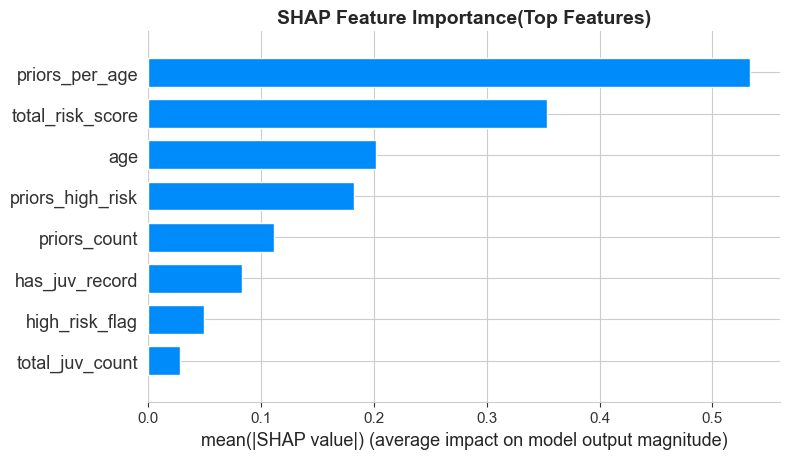


 SHAP Summary Plot- Detailed


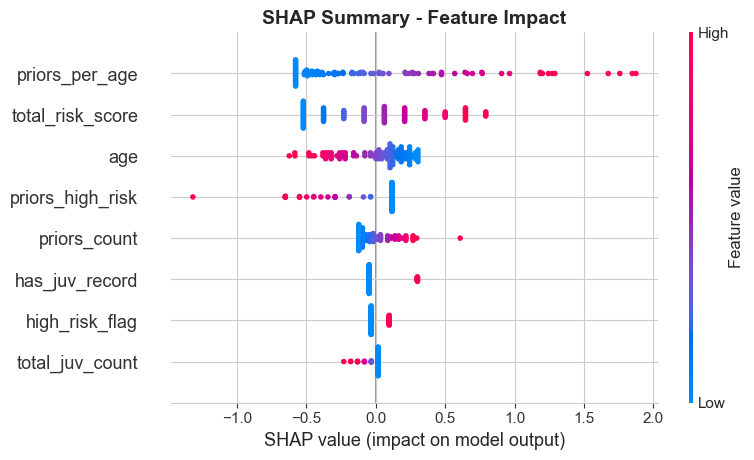


 SHAP ANALYSIS COMPLETE!


In [22]:
#SHAP ANALYSIS
import shap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

print("="*60)
print("Shap analysis")
print("="*60)

save_path = "./models"
model = joblib.load(os.path.join(save_path, "best_model_optimized.pkl"))

print(f"\n Model loaded: {save_path}")

features = ['age', 'priors_count', 'priors_per_age', 'total_risk_score', 
            'total_juv_count', 'priors_high_risk', 'high_risk_flag', 'has_juv_record']

X_sample = X_test[features].sample(n=100, random_state=42)

print(f"\n Sample size for SHAP: {len(X_sample)}")

#exlainer for SHAP
print("n\ Creating SHAP explainer...")

lr_model = model.named_steps['lr']

explainer = shap.LinearExplainer(lr_model, X_sample)
shap_values = explainer.shap_values(X_sample)

print("SHAP EXPLAINER CREATED")

#SHAP bar plot -TOP FEATURES
shap_importance = pd.DataFrame({
    'Feature': X_sample.columns,
    'Importance': np.abs(shap_values).mean(axis=0)
}).sort_values('Importance', ascending=False)

print("n\ Top 5 features:")
for i, row in shap_importance.head(5).iterrows():
    print(f" {i+1}. {row['Feature']}: {row['Importance']:.4f}")

print("\n Shap Bar Plot - Top Features")

plt.figure(figsize=(10,8))
shap.summary_plot(shap_values, X_sample, plot_type="bar", show=False)
plt.title('SHAP Feature Importance(Top Features)', fontsize = 14, fontweight= 'bold')
plt.tight_layout()
plt.show()

#SHAP summary plot detailed
print("\n SHAP Summary Plot- Detailed")
plt.figure(figsize=(12,8))
shap.summary_plot(shap_values, X_sample, show=False)
plt.title('SHAP Summary - Feature Impact', fontsize=14, fontweight= 'bold')
plt.tight_layout()
plt.show()

print("\n SHAP ANALYSIS COMPLETE!")

 Time Data Overview

 Time columns available:
 start
 end

 Time statistics:
   - Min days: -256
   - Max days: 1186
   - Mean days: 542
   - Median days: 509

 Cases <= 2 years (730 days):
   - Total: 3,993 (55.4%)
   - Recidivism within 2 years: 2,617 (94.75%)

 Cases > 2 years (730 days):
   - Total cases > 2 years: 3,221 (44.6%)
   - Recidivism after 2 years: 145 (5.25%)


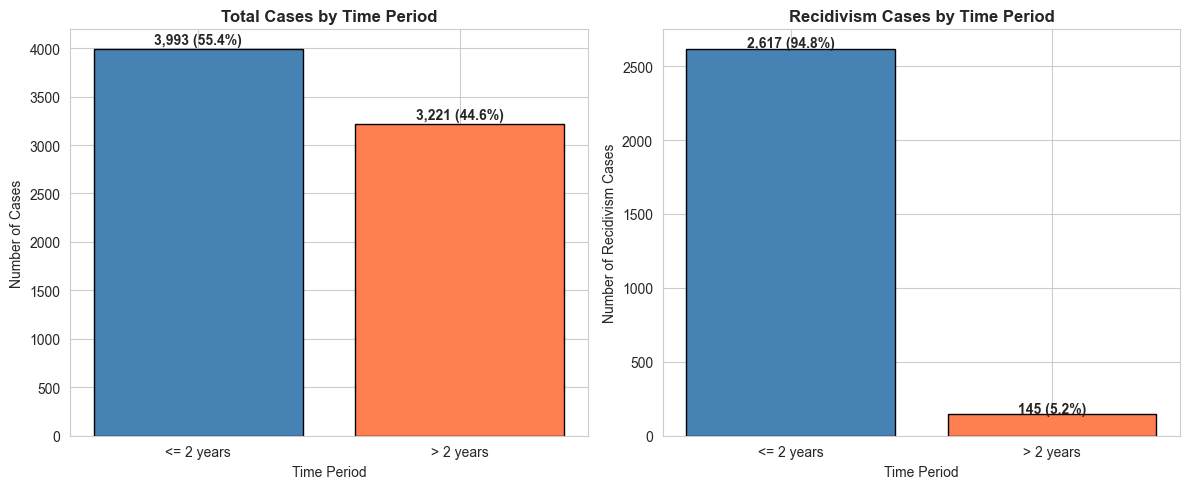

In [41]:
print("="*60)
print(" Time Data Overview")
print("="*60)

print("\n Time columns available:")
time_cols = ['start', 'end', 'time_to_recid']

for col in time_cols:
    if col in df_surv.columns:
        print(f" {col}")

print("\n Time statistics:")

# Calculate time in days
df_surv['time'] = df_surv['end'] - df_surv['start']

print(f"   - Min days: {df_surv['time'].min():.0f}")
print(f"   - Max days: {df_surv['time'].max():.0f}")
print(f"   - Mean days: {df_surv['time'].mean():.0f}")
print(f"   - Median days: {df_surv['time'].median():.0f}")

print("\n Cases <= 2 years (730 days):")

under_730 = df_surv[df_surv['time'] <= 730]
recid_under_730 = under_730[under_730['event'] == 1]
print(f"   - Total: {len(under_730):,} ({len(under_730)/len(df_surv)*100:.1f}%)")
print(f"   - Recidivism within 2 years: {len(recid_under_730):,} ({len(recid_under_730)/df_surv['event'].sum()*100:.2f}%)")

print("\n Cases > 2 years (730 days):")

over_730 = df_surv[df_surv['time'] > 730]
recid_over_730 = over_730[over_730['event'] == 1]

print(f"   - Total cases > 2 years: {len(over_730):,} ({len(over_730)/len(df_surv)*100:.1f}%)")
print(f"   - Recidivism after 2 years: {len(recid_over_730):,} ({len(recid_over_730)/df_surv['event'].sum()*100:.2f}%)")

df_surv['period_category'] = df_surv['time'].apply(
    lambda x: '<= 2 years' if x <= 730 else '> 2 years'
)

period_counts = df_surv['period_category'].value_counts()
recid_counts = df_surv[df_surv['event'] == 1]['period_category'].value_counts()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

colors = ['steelblue', 'coral']
bars1 = ax1.bar(period_counts.index, period_counts.values, color=colors, edgecolor='black')
ax1.set_title('Total Cases by Time Period', fontsize=12, fontweight='bold')
ax1.set_ylabel('Number of Cases')
ax1.set_xlabel('Time Period')

for bar, val in zip(bars1, period_counts.values):
    pct = val / len(df_surv) * 100
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50, 
             f'{val:,} ({pct:.1f}%)', ha='center', fontweight='bold')

bars2 = ax2.bar(recid_counts.index, recid_counts.values, color=colors, edgecolor='black')
ax2.set_title('Recidivism Cases by Time Period', fontsize=12, fontweight='bold')
ax2.set_ylabel('Number of Recidivism Cases')
ax2.set_xlabel('Time Period')

for bar, val in zip(bars2, recid_counts.values):
    pct = val / df_surv['event'].sum() * 100
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10, 
             f'{val:,} ({pct:.1f}%)', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()


In [23]:
#Survival Analysis 
from lifelines import KaplanMeierFitter, CoxPHFitter
import warnings 
warnings.filterwarnings('ignore')

print("="*60)
print("Survival Analysis - Step 1")
print("="*60)

df_surv = df_model.copy()

#calculate time until recid(days)
df_surv['time'] = df_surv['end'] - df_surv['start']
df_surv['time'] = df_surv['time'].clip(lower=0)

print(f"\n Date Ready:")
print(f" Rows: {len(df_surv):,}")
print(f" Medium time until recidivism: {df_surv['time'].mean():.0f} zile")
print(f"Cases with rec: {df_surv['event'].sum():,}")

Survival Analysis - Step 1

 Date pregatite:
 Randuri: 7,214
 Timp mediu pana la recidiva: 542 zile
 Cazuri cu recidiva: 2,762



Step 2 General Survival Curbe

 Statistics:
 Median Survival time: inf days
 Recidivism events: 2,762
 Censored ( no recidivism) : 4,452


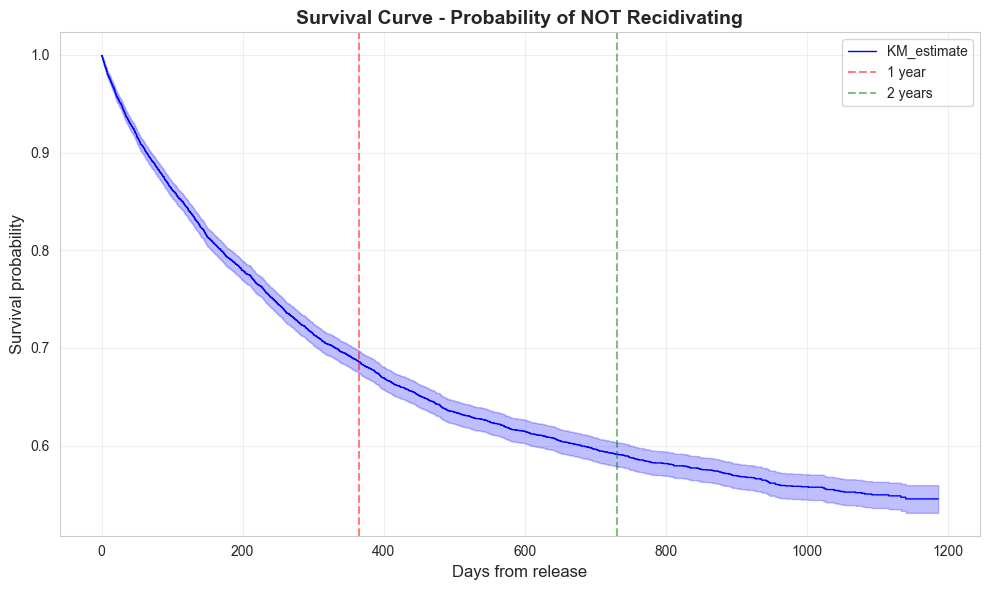

In [28]:
print("\n" + "="*60)
print("Step 2 General Survival Curbe")
print("="*60)

#Kaplan-Meier Model
kmf = KaplanMeierFitter()
kmf.fit(durations=df_surv['time'], event_observed=df_surv['event'])

print(f"\n Statistics:")
print(f" Median Survival time: {kmf.median_survival_time_:.0f} days")
print(f" Recidivism events: {df_surv['event'].sum():,}")
print(f" Censored ( no recidivism) : {(df_surv['event'] == 0).sum():,}")

plt.figure(figsize=(10,6))
kmf.plot_survival_function(color='blue', linewidth=1)
plt.title('Survival Curve - Probability of NOT Recidivating', fontsize=14, fontweight='bold')
plt.xlabel('Days from release', fontsize=12)
plt.ylabel('Survival probability', fontsize=12)
plt.grid(True, alpha=0.3)
plt.axvline(x=365, color='red', linestyle='--', alpha=0.5, label='1 year')
plt.axvline(x=730, color='green', linestyle='--', alpha=0.5, label= '2 years')
plt.legend()
plt.tight_layout()
plt.show()


Comparison by age groups -Step2


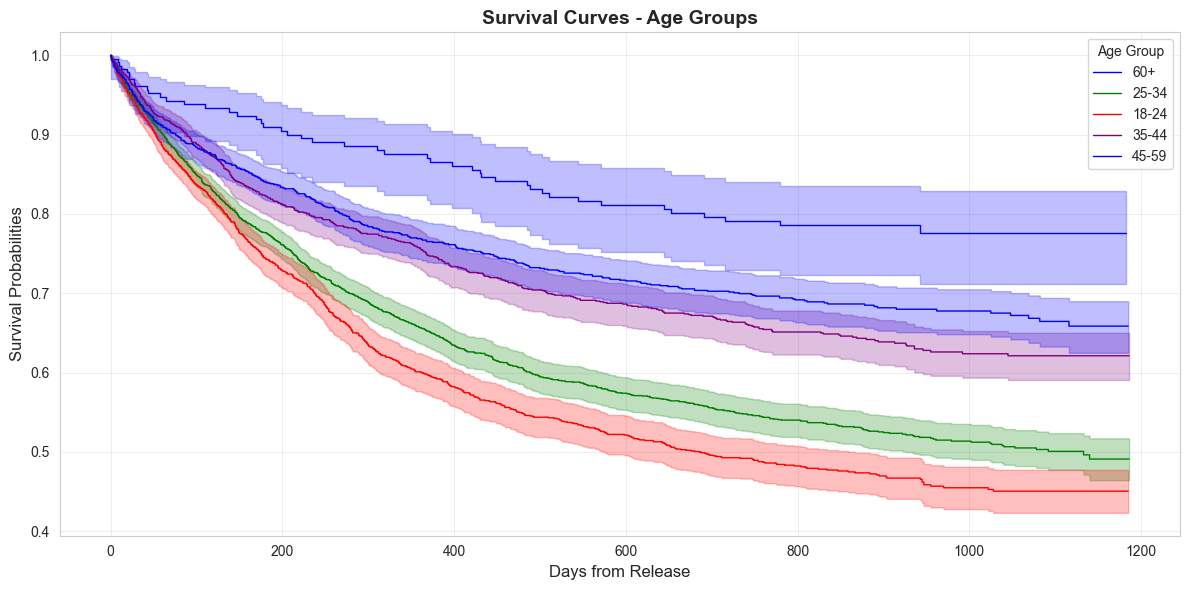


 Comparison by Sex:


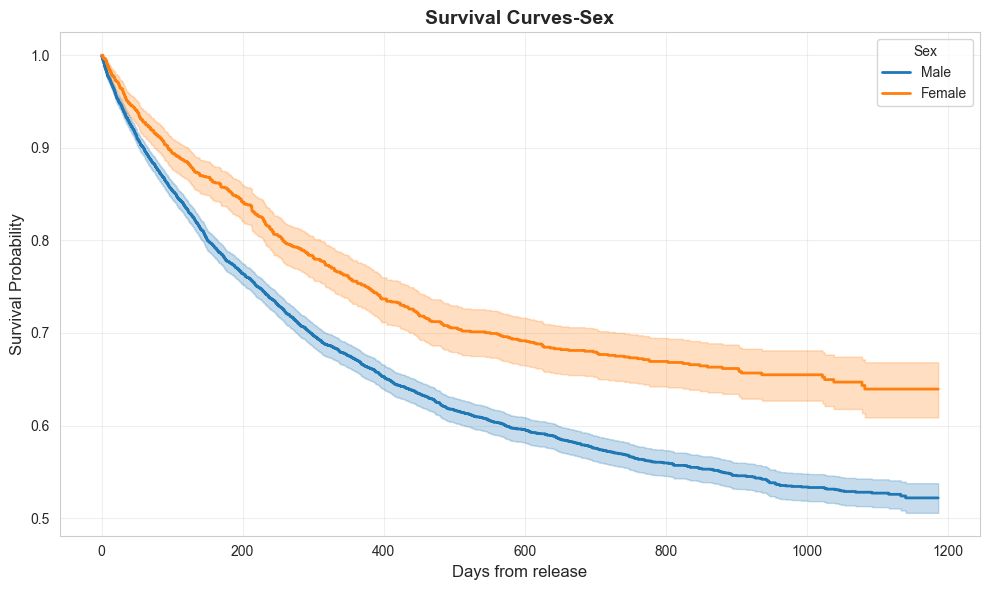

In [31]:
print("\n" + "="*60)
print("Comparison by age groups -Step2")
print("="*60)

df_surv['age_group'] = pd.cut(df_surv['age'], bins=[0,25,35,45,60,100], labels=['18-24', '25-34', '35-44', '45-59', '60+'])

plt.figure(figsize=(12, 6))
colors = ['blue', 'green', 'red', 'purple']

for i, group in enumerate(df_surv['age_group'].unique()):
    if pd.notna(group):
        data = df_surv[df_surv['age_group'] == group]
        kmf_g = KaplanMeierFitter()
        kmf_g.fit(durations=data['time'], event_observed=data['event'], label=group)
        kmf_g.plot_survival_function(color=colors[i % len(colors)], linewidth=1)

plt.title('Survival Curves - Age Groups', fontsize=14, fontweight='bold')
plt.xlabel('Days from Release', fontsize=12)
plt.ylabel('Survival Probabilities', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend(title='Age Group')
plt.tight_layout()
plt.show()

print("\n Comparison by Sex:")

plt.figure(figsize=(10, 6))
for sex in df_surv['sex'].unique():
    data = df_surv[df_surv['sex'] == sex]
    kmf_s = KaplanMeierFitter()
    kmf_s.fit(durations=data['time'], event_observed=data['event'], label=sex)
    kmf_s.plot_survival_function(linewidth=2)

plt.title('Survival Curves-Sex', fontsize=14, fontweight='bold')
plt.xlabel('Days from release', fontsize=12)
plt.ylabel('Survival Probability', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend(title='Sex')
plt.tight_layout()
plt.show()



Critical Risk Window - Step4

 Recidivism rate by period:
 - 0-3 months: 65.6%
 - 3-6 months: 65.5%
 - 6-12 months: 68.5%
 - 1-2 years: 62.3%
 - >2 years: 6.3%


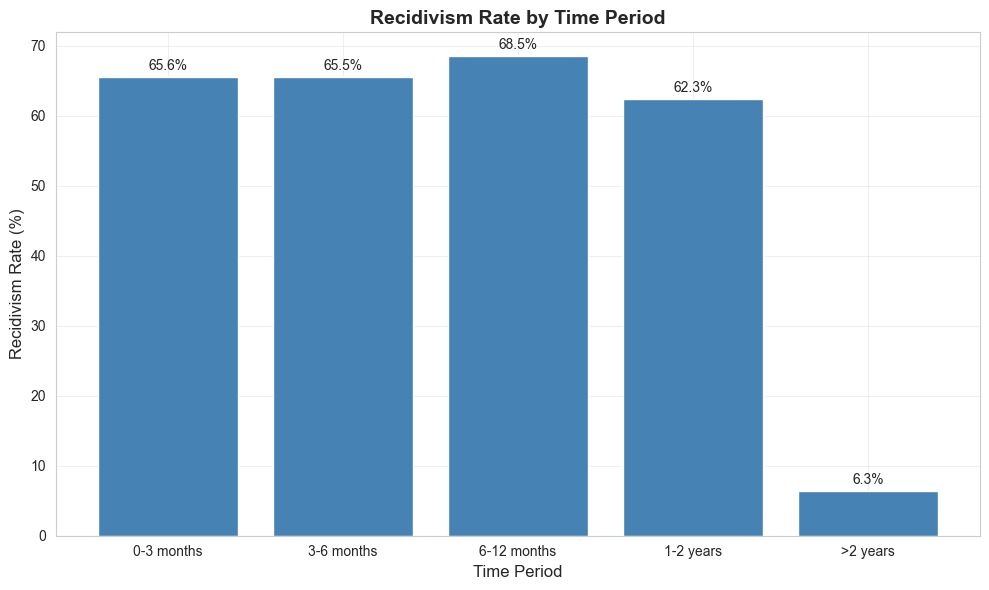


 Critical Window: 6-12 months (68.5% of recidivism)


In [35]:
print("\n" + "="*60)
print("Critical Risk Window - Step4")
print("="*60)

bins = [0, 90, 180, 365, 730, 1000]
labels = ['0-3 months', '3-6 months', '6-12 months', '1-2 years', '>2 years']

df_surv['period'] = pd.cut(df_surv['time'], bins=bins, labels=labels)

recid_by_period = df_surv[df_surv['event'] == 1].groupby('period').size()
total_by_period = df_surv.groupby('period').size()
rate_by_period = (recid_by_period / total_by_period * 100).fillna(0)

print("\n Recidivism rate by period:")
for period, rate in rate_by_period.items():
    if rate > 0:
        print(f" - {period}: {rate:.1f}%")

plt.figure(figsize=(10,6))
plt.bar(rate_by_period.index, rate_by_period.values, color='steelblue')
plt.title('Recidivism Rate by Time Period', fontsize=14, fontweight='bold')
plt.xlabel('Time Period', fontsize=12)
plt.ylabel('Recidivism Rate (%)', fontsize=12)
for i, v in enumerate(rate_by_period.values):
    if v > 0:
        plt.text(i, v + 1, f'{v:.1f}%', ha='center')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

critical_period = rate_by_period.idxmax()
critical_rate = rate_by_period.max()
print(f"\n Critical Window: {critical_period} ({critical_rate:.1f}% of recidivism)")




In [42]:
print("\n" + "="*60)
print("Key Findings")
print("="*60)

critical_period = rate_by_period.idxmax()
critical_rate = rate_by_period.max()

print(f"\n CRITICAL RISK WINDOW:")
print(f"   - Highest risk: {critical_period}")
print(f"   - {critical_rate:.1f}% of recidivism occurs in this period")

median_time = df_surv[df_surv['event'] == 1]['time'].median()
mean_time = df_surv[df_surv['event'] == 1]['time'].mean()

print(f"\n TIME TO RECIDIVISM:")
print(f"   - Mean: {mean_time:.0f} days")
print(f"   - Median: {median_time:.0f} days")



Key Findings

 CRITICAL RISK WINDOW:
   - Highest risk: 6-12 months
   - 68.5% of recidivism occurs in this period

 TIME TO RECIDIVISM:
   - Mean: 245 days
   - Median: 172 days


In [43]:
#final deployment
import pandas as pd
import joblib
import os
import json
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

print("="*60)
print("FINAL DEPLOYMENT")
print("="*60)

save_path = "./models"
os.makedirs(save_path, exist_ok=True)
print(f"\n Save path: {save_path}")

model = joblib.load(os.path.join(save_path, "best_model_optimized.pkl"))
print(" Model loaded")

features = ['age', 'priors_count', 'priors_per_age', 'total_risk_score', 
            'total_juv_count', 'priors_high_risk', 'high_risk_flag', 'has_juv_record']

class RecidivismPredictor:
    def __init__(self, model_path):
        self.model = joblib.load(model_path)
        self.features = features
        self.threshold_low = 0.4
        self.threshold_high = 0.7
    
    def predict(self, data):
        X = data[self.features].copy()
        preds = self.model.predict(X)
        probs = self.model.predict_proba(X)[:, 1]
        return {
            'predictions': preds.tolist(),
            'probabilities': probs.tolist(),
            'risk_levels': ['High' if p >= 0.7 else 'Medium' if p >= 0.4 else 'Low' for p in probs]
        }
    
    def predict_single(self, age, priors_count, priors_per_age, total_risk_score,
                       total_juv_count, priors_high_risk, high_risk_flag, has_juv_record):
        data = pd.DataFrame([[
            age, priors_count, priors_per_age, total_risk_score,
            total_juv_count, priors_high_risk, high_risk_flag, has_juv_record
        ]], columns=self.features)
        result = self.predict(data)
        return {
            'probability': result['probabilities'][0],
            'prediction': 'Recidivism' if result['predictions'][0] == 1 else 'No Recidivism',
            'risk_level': result['risk_levels'][0]
        }
predictor = RecidivismPredictor(os.path.join(save_path, "best_model_optimized.pkl"))
joblib.dump(predictor, os.path.join(save_path, "predictor.pkl"))
print(" Predictor saved")

config = {
    'model': 'Logistic Regression with SMOTE',
    'version': '1.0.0',
    'created': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    'features': features,
    'thresholds': {'low': 0.4, 'high': 0.7, 'classification': 0.5},
    'survival_analysis': {
        'critical_window': '6-12 months',
        'critical_rate': '68.5%',
        'median_time': '172 days',
        'mean_time': '245 days'
    }
}

with open(os.path.join(save_path, "config.json"), 'w') as f:
    json.dump(config, f, indent=4)
print(" Config saved")

print("\n Testing Predictor")

test_data = pd.DataFrame({
    'age': [25, 35, 45, 18],
    'priors_count': [3, 0, 8, 15],
    'priors_per_age': [0.12, 0.00, 0.18, 0.83],
    'total_risk_score': [8, 4, 12, 15],
    'total_juv_count': [1, 0, 2, 5],
    'priors_high_risk': [3, 0, 8, 15],
    'high_risk_flag': [1, 0, 1, 1],
    'has_juv_record': [1, 0, 1, 1]
})

results = predictor.predict(test_data)

print("\n Test Results:")
for i in range(len(test_data)):
    print(f"   Case {i+1}: Age {test_data['age'].iloc[i]}, Priors {test_data['priors_count'].iloc[i]} → {results['probabilities'][i]:.1%} ({results['risk_levels'][i]})")




FINAL DEPLOYMENT

 Save path: C:\Users\gm_sl\ML RECIDIVA
 Model loaded
 Predictor saved
 Config saved

 Testing Predictor

 Test Results:
   Case 1: Age 25, Priors 3 → 7.2% (Low)
   Case 2: Age 35, Priors 0 → 0.1% (Low)
   Case 3: Age 45, Priors 8 → 0.2% (Low)
   Case 4: Age 18, Priors 15 → 73.6% (High)


In [44]:
print("\n" + "="*60)
print(" DEPLOYMENT SUMMARY")
print("="*60)
print(f"""
 Files: best_model_optimized.pkl, predictor.pkl, config.json
 ROC-AUC: 0.7437 | Accuracy: 0.6958
 Critical window: 6-12 months (68.5% of recidivism)
 Use: predictor = joblib.load('predictor.pkl')
""")
print("="*60)
print(" DEPLOYMENT COMPLETE!")


 DEPLOYMENT SUMMARY

 Files: best_model_optimized.pkl, predictor.pkl, config.json
 ROC-AUC: 0.7437 | Accuracy: 0.6958
 Critical window: 6-12 months (68.5% of recidivism)
 Use: predictor = joblib.load('predictor.pkl')

 DEPLOYMENT COMPLETE!
